#Predicting In-Hospital Cardiac Arrest in Sepsis Patients


## *Table of Contents*
1.  Introduction
*   Background and Context
*   Research Question
*   Summary of Results
*   Data Collection and Cleaning Summary
2.  Data Description
3.  Preregistration Statement
4. Data Analysis
* Hypothesis 1
* Hypothesis 2
5. Evaluation of Significance
6. Interpretation and Conclusions
7. Limitations
9. Acknowledgements


## Part 1. Introduction

Sepsis is a leading cause of ICU mortality, and timely identification of patients at risk for deterioration remains a critical challenge. This project investigates whether routinely collected electronic health record (EHR) data can be used to predict in-hospital cardiac arrest among sepsis patients.

These questions are motivated by clinical intuition and prior literature suggesting that age and acuity at admission are strong predictors of adverse outcomes. Studies using ICU datasets and large multi-hospital cohorts have demonstrated that EHR-based early warning systems, like leveraging vital signs, laboratory trends, and organ-failure scores, can identify patients at high risk for clinical deterioration several hours before the event. However, existing prediction models often struggle with generalizability, transparency, and timely integration into real-world ICU workflows, leading to delays in clinical response. Because cardiac arrest in septic patients carries extremely high mortality, but symptoms can be small and can easily be missed, improving early prediction has substantial clinical value: it enables faster intervention, more efficient allocation of ICU resources, and the potential to prevent irreversible damage. Understanding which features such as age, admission type, or specific physiological markers, contribute most to risk can also help clinicians make more informed decisions and support the development of reliable, reproducible early-warning tools for bedside use. The goal of our research is to begin by producing interpretable, reproducible analyses that could inform future deployment in ICU settings.

Our **primary research question** is:

### Can we build an early warning model that predicts in-hospital cardiac arrest in sepsis patients using features available up to 6 hours before the event?



We also explore **two secondary questions**:
### Are older patients (age > 65) at higher risk of cardiac arrest?

###Is admission type (emergency vs urgent) associated with arrest risk?


Regarding the results of our analyses, we reached mixed conclusions across our two preregistered hypotheses. To study our first subquestion on whether age is associated with cardiac arrest, we ran two logistic regressions: one using an age ≥ 65 cutoff and one treating age as a continuous variable. Both models yielded statistically significant results (p-values: 0.0168 and 0.0030), although the direction of the effect was opposite to our expectation—older patients actually had lower odds of cardiac arrest.

To investigate our second subquestion on whether cardiac arrest is associated with ICU length of stay, we used a Mann-Whitney U test due to the skewed nature of LOS. This test produced a p-value of 0.047, allowing us to reject the null hypothesis and conclude that LOS distributions differ significantly between arrest and non-arrest patients. Although our accompanying OLS regression did not show a significant mean difference, the non-parametric test provided stronger evidence for this association.

## 2. Data Description & Data Cleaning

### Note this is only a summary of what was covered in Phase 2.
**Cleaned data were generated in our separated Phase 2 notebook ([see GitHub link](https://github.com/justwan66/PHASE1-MIMIC-III-DATASET/blob/main/PHASE_II.ipynb)) and imported as .csv files.**

**Dataset Origin:**  
MIMIC-III v1.4, Beth Israel Deaconess Medical Center ICU patients (2001–2012). Link: [https://physionet.org/content/mimiciii/1.4/](https://physionet.org/content/mimiciii/1.4/)


To study sepsis patients and their risk of in‑hospital cardiac arrest, we curated a unified dataset from the **MIMIC‑III database**. The raw data came from three core tables — `ADMISSIONS.csv`, `ICUSTAYS.csv`, and `TRANSFERS.csv` — each containing overlapping but distinct information about hospital admissions, ICU stays, and patient transfers.  

**Why we cleaned the data:**  
The original tables contained many administrative or redundant columns (e.g., internal row IDs, database source flags, ward identifiers, insurance, language, religion). These fields were not relevant to our clinical research questions and would add unnecessary complexity. Cleaning ensured that only clinically meaningful variables remained, making the dataset easier to interpret, reproducible, and aligned with our hypotheses.

**How we cleaned the data:**  
- **Column reduction:** We dropped unused identifiers and administrative fields from each table:
  - `TRANSFERS`: removed row IDs, database source, and redundant care unit/ward columns.  
  - `ICUSTAYS`: removed row IDs, database source, and first/last care unit/ward identifiers.  
  - `ADMISSIONS`: removed row IDs, admission/discharge location, insurance, language, religion, marital status, ED timestamps, and flags not needed for analysis.  
- **Merging tables:** We merged ICU stays with admission‑level information using `SUBJECT_ID` and `HADM_ID`, then optionally added transfer data to capture care unit trajectories.  
- **Cohort definition:** Using the cleaned dataset, we flagged patients with sepsis (`DIAGNOSIS` contains “SEPSIS”) and those with cardiac arrest (`DIAGNOSIS` contains “CARDIAC ARREST”). We then created a combined cohort of sepsis and arrest patients.  

**Result:** The final cohort contained **2,516 sepsis patients** and **377 cardiac arrest patients**, with a combined dataset of **2,893 patients**. Importantly, we noted that the cardiac arrest group only included patients admitted for arrest, not those who experienced arrest later in their stay.

By cleaning and merging the data in this way, we created a streamlined, clinically relevant dataset that links ICU stays with hospital‑level details and care unit trajectories. This curated cohort provides a reproducible foundation for hypothesis testing — specifically, examining how sepsis patients differ from those who experience cardiac arrest, and identifying risk factors that could inform early warning models.  


In [ ]:
# imports and settings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
df_adm=pd.read_csv('ADMISSIONS.csv')
df_icu=pd.read_csv('ICUSTAYS.csv')
df_transf=pd.read_csv('TRANSFERS.csv')

# Below are the columns for each of the csv files.
# We will begin by removing columns of each csv that we will not use in our analysis.
throwaway_cols_transf=[
"ROW_ID","DBSOURCE", "PREV_CAREUNIT","PREV_WARDID","CURR_WARDID"
]
df_transf.drop(columns=throwaway_cols_transf,axis=1,inplace=True)

throwaway_cols_icu=["ROW_ID","DBSOURCE","FIRST_CAREUNIT", "FIRST_WARDID","LAST_WARDID"]
df_icu.drop(columns=throwaway_cols_icu,axis=1,inplace=True)

throwaway_cols_adm=["ROW_ID","ADMISSION_LOCATION","DISCHARGE_LOCATION", "INSURANCE","LANGUAGE",
"RELIGION","MARITAL_STATUS", "EDREGTIME","EDOUTTIME","HOSPITAL_EXPIRE_FLAG","HAS_CHARTEVENTS_DATA"]
df_adm.drop(columns=throwaway_cols_adm,axis=1,inplace=True)

# This code loads the 3 tables and merges them to create a unified dataset linking
#each ICU stay with hospital-level admission details and current care unit information.
adm = pd.read_csv('ADMISSIONS.csv', parse_dates=['ADMITTIME', 'DISCHTIME', 'DEATHTIME'])
icu = pd.read_csv('ICUSTAYS.csv', parse_dates=['INTIME', 'OUTTIME'])
trans = pd.read_csv('TRANSFERS.csv', parse_dates=['INTIME', 'OUTTIME'])

# Merge ICU stays with admission-level info
merged = icu.merge(adm, on=['SUBJECT_ID', 'HADM_ID'], how='inner')

# Optionally add transfers for care unit trajectory
merged = merged.merge(trans[['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'CURR_CAREUNIT']],
                      on=['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID'], how='left')



In [ ]:
sepsis_df = merged[merged['DIAGNOSIS'].str.contains('SEPSIS', case=False, na=False)]
print("Sepsis patients:", len(sepsis_df))

arrest_df = merged[merged['DIAGNOSIS'].str.contains('CARDIAC ARREST', case=False, na=False)]
print("Cardiac arrest patients:", len(arrest_df))

Sepsis patients: 2516
Cardiac arrest patients: 377


In [ ]:
merged['IS_SEPSIS'] = merged['DIAGNOSIS'].str.contains('SEPSIS', case=False, na=False)
merged['IS_ARREST'] = merged['DIAGNOSIS'].str.contains('CARDIAC ARREST', case=False, na=False)

cohort = merged[(merged['IS_SEPSIS'] == True) | (merged['IS_ARREST'] == True)]
print("Combined sepsis/cardiac arrest cohort size:", len(cohort))

Combined sepsis/cardiac arrest cohort size: 2893


### A) Motivation

**What are the observations (rows) and the attributes (columns)?**


Column (all unique columns from transfers.csv, icustays.csv, & admission.csv)

* **ADMISSION_LOCATION:** Where the patient was immediately before hospital admission (e.g., “TRANSFER FROM HOSPITAL,” “EMERGENCY ROOM”).
* **ADMISSION_TYPE:** Category of admission such as “ELECTIVE,” “EMERGENCY,” or “URGENT.”
* **ADMITTIME:** Date and time the patient was admitted to the hospital.
* **CURR_CAREUNIT:** The ICU care unit the patient is currently located in for that transfer record.
* **CURR_WARDID:** Numeric identifier for the ward the patient is currently assigned to.
* **DBSOURCE:** Indicates whether the record came from the CareVue or MetaVision database system.
* **DEATHTIME:** Timestamp of death if the patient died during the hospital stay; otherwise blank.
* **DIAGNOSIS:** Primary admission diagnosis text recorded by hospital staff.
* **DISCHARGE_LOCATION:** Where the patient went after discharge (e.g., “HOME,” “REHAB,” “SNF”).
* **DISCHTIME:** Date and time the patient was discharged from the hospital.
* **EDOUTTIME:** Time the patient left the emergency department, if applicable.
* **EDREGTIME:** Time the patient was first registered or arrived in the emergency department.
* **ETHNICITY:** Patient’s recorded ethnicity as entered in the hospital system.
* **EVENTTYPE:** Type of transfer event (e.g., “admit,” “transfer,” or “discharge”) within the hospital.
* **FIRST_CAREUNIT:** The first ICU care unit where the patient was admitted during the ICU stay.
* **FIRST_WARDID:** Numeric identifier for the ward corresponding to the first ICU location.
* **HAS_CHARTEVENTS_DATA:** Binary flag (1/0) indicating whether charted time-series data exist for the hospital admission.
* **HADM_ID:** Unique integer identifying a single hospital admission (linkable across tables).
* **HOSPITAL_EXPIRE_FLAG:** 1 if the patient died during the hospital stay, 0 otherwise.
* **ICUSTAY_ID:** Unique integer identifying one ICU stay; a hospital admission can have multiple ICU stays.
* **INSURANCE:** Patient’s insurance category (e.g., “Medicare,” “Private,” “Self Pay”).
* **INTIME:** Time the patient entered the ICU or care unit.
* **LANGUAGE:** Primary language recorded for the patient.
* **LAST_CAREUNIT:** ICU care unit where the patient was located at the end of the ICU stay.
* **LAST_WARDID:** Numeric identifier for the ward associated with the last ICU location.
* **LOS:** Length of stay, typically in days, calculated from INTIME and OUTTIME.
* **MARITAL_STATUS:** Patient’s marital status (e.g., “MARRIED,” “SINGLE”).
* **OUTTIME:** Time the patient left the ICU or care unit.
* **PREV_CAREUNIT:** The previous ICU care unit before the current transfer (used in TRANSFERS).
* **PREV_WARDID:** Numeric identifier for the ward the patient was in before the current transfer.
* **RELIGION:** Patient’s self-reported religion recorded at admission.
* **ROW_ID:** Internal numeric key used by the database to uniquely identify each row.
* **SUBJECT_ID:** Unique patient identifier that links all of a patient’s admissions and stays across tables.



**Who funded the creation of the dataset?**

This research and development was supported by grants NIH-R01-EB017205, NIH-R01-EB001659, and NIH-R01-GM104987 from the National Institutes of Health.

**Why was this dataset created?**


The data set was created to address the challenge of interoperability and reproducibility. Because hospital digital systems often cannot share or integrate data effectively, valuable clinical information remains underused. A standardized dataset helps overcome this by providing a common and practical structure for hospital data, enabling intergration and analysis across systems. Additionally, the scientific community's reproducibility crisis means that many studies cannot be reliably repeated due to inconsistent or inaccessible data. The dataset was therefore created to promote transparency and reproducibility in health data research but offering a curated and accessible source of data

### B) Composition

**What do the instances that comprise the dataset represent. How many instances are there in total?**

In this project, each instance represents a single ICU stay for a hospitalized patient. We then restricted the dataset to patients whose admission diagnosis included the word “SEPSIS” or “CARDIAC ARREST.” There are 2893 instances in total.

**If people are involved, were they aware of the data collection and if so, what purpose did they expect the data to be used for?**

Because consent was waived and data was collected as part of routine care, it is very unlikely that each patient was explicitly informed that their data would later be used in this research database. From the project side, the expectation was that by de-identifying the data and obtaining IRB approval with the waiver of consent, the data could ethically be reused for research.

**Is any information missing from individual instances?**


In particular, the diagnosis text used to identify sepsis or cardiac arrest is not always available; some ICU stays lack complete care-unit information, such as LAST_CAREUNIT, and a subset of admissions do not have a recorded DEATHTIME, which prevents us from determining in-hospital mortality for those cases. As a result, several analyses rely on subsets of the cohort with complete information, but this missingness does not prevent us from performing the core hypothesis tests.

### C) Collection Process

**What processes might have influenced what data was observed and recorded and what was not?**

1. Routine clinical care vs research-driven recording

The dataset was collected during routine hospital care, not for the primary purpose of research. Becuase of this, clinical priorities drive what gets recorded. Therefore, the dataset is biased toward what clinicians and hospital systems deem relevant to care rather than providing everything about the patient.

2. Workflow and human factors

Measurements (vitals, labs) often depend on nurse/clinician documentation, device-reading, and therefore are subject to timing, missingness and accuracy. The recorded data reflects the clinical context rather than an ideal systematic measurement plan.



### D) Preprocessing/Cleaning/Labeling

**What preprocessing was done, and how did the data come to be in the form that you are using?**

1. Data Sources

ICU patient care data from two distinct crtical care information systems: Philips CareVue Clinical Information System and iMDsoftMetaVision ICU. Hospital EHR databases capturing: patient demographics, admissions & discharges, hospital-wide labs, billing and diagnostic codes. Mortality information from the Social Security Administration Death Master File for out-of-hospital deaths.

2. De-identification and Privacy Measures

Removed all HIPAA indentifiers (name, address, phone number). For each patient, a consistent random offset was applied so that real calendar dates are obscure but relative intervals are preserved. For patients aged 89+ years old, the date of birth was shifted to make them appear with ages 300+ years old to meet de-identification requirements.

3. Harmonisation & Integration of Multiple Systems

Data from CareVue and MetaVision were merged where possible. For events that couldn't be harmonised, seperate tables were maintained (INPUTEVENTS_CV for CareVue vs INPUTEVENTS_MV for MetaVision). Standardisation of coding systems: lab test ITEMIDs, diagnosis ICD-9 codes, procedure codes (CPT/ICD9), dictionary tables. Filtering out implausible data.

4. Creation of Relational Schema & Tabular Format

Data were stored as a relational database comprising 26 tables. Files are distributed as CSV files and can be imported into database systems.

5. Time-alignment

Timestamps were preserved in relative terms but the absolute calendar year is shifted/disguised.

**Where our raw source data can be found:**

https://github.com/justwan66/PHASE1-MIMIC-III-DATASET/tree/main/MIMIC-III_datasets

**Citation of Database**

Johnson, Alistair, et al. *“MIMIC-III Clinical Database” (version 1.4).* PhysioNet, 2016. [https://doi.org/10.13026/C2XW26](https://doi.org/10.13026/C2XW26). ([physionet.org][1])

[1]: https://physionet.org/content/mimiciii/1.4/?utm_source=chatgpt.com "MIMIC-III Clinical Database v1.4 - PhysioNet"



## 3. Preregistration Statements

### **Hypothesis 1: Age and Cardiac Arrest**

- **H₀:**  There is no association between being over age 65 and experiencing in‑hospital cardiac arrest among sepsis patients.  

- **Hₐ:**  Patients over age 65 are more likely to experience in-hospital cardiac arrest than younger patients.  

##### We would accept p-values that are less than 0.05 to suggest that there is statistical significance to reject the null hypothesis in favor of the alternative.


### **Hypothesis 2: Admission Type and Cardiac Arrest**

- **H₀:**  Admission type (emergency vs urgent) is independent of in-hospital cardiac arrest occurrence among sepsis patients.  

- **Hₐ:**  Sepsis patients admitted as emergencies are more likely to experience in-hospital cardiac arrest than those admitted urgently.  
##### For hypothesis two we would also accept a p-value less than 0.05 to suggest that there is statistical significance to reject the null hypothesis in favor of the alternative.


## 4. Data Analysis

### **Hypothesis 1: Age and Cardiac Arrest**


**Do certain ages correlate to differences in in-hospital cardiac arrest likelihoods?**


H₀: There is no association between being over age 65 and experiencing in‑hospital cardiac arrest among sepsis patients.


Hₐ: Patients over age 65 are more likely to experience in‑hospital cardiac arrest than younger patients.


### Rationale

We want to examine whether age plays a role in the likelihood of experiencing in-hospital cardiac arrest among sepsis patients. Older adults may have reduced physiological reserve, more comorbidities, and different responses to critical illness, which could increase their risk of arrest. To test this, we use logistic regression with a binary age cutoff (over 65) to estimate the odds of arrest in older versus younger patients. This approach allows us to quantify the association while adjusting for binary predictors. Since age is continuous, we also explore an alternative model using age as a numeric variable to assess whether risk increases steadily with age rather than abruptly at 65. Together, these models help clarify whether age is a meaningful predictor of cardiac arrest in this cohort.

In [ ]:
patients = pd.read_csv('PATIENTS.csv', parse_dates=['DOB'])

# Merge date of birth (DOB) into your Phase 2 cohort
cohort = cohort.merge(patients[['SUBJECT_ID','DOB']], on='SUBJECT_ID', how='left')
cohort.head()

,ROW_ID_x,SUBJECT_ID,HADM_ID,ICUSTAY_ID,DBSOURCE,FIRST_CAREUNIT,LAST_CAREUNIT,FIRST_WARDID,LAST_WARDID,INTIME,...,ETHNICITY,EDREGTIME,EDOUTTIME,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,HAS_CHARTEVENTS_DATA,CURR_CAREUNIT,IS_SEPSIS,IS_ARREST,DOB
0,366,269,106296,206613,carevue,MICU,MICU,52,52,2170-11-05 11:05:29,...,WHITE,2170-11-05 07:22:00,2170-11-05 12:15:00,SEPSIS;PILONIDAL ABSCESS,0,1,MICU,True,False,2130-09-30
1,372,275,129886,219649,carevue,CCU,CCU,7,7,2170-10-07 11:28:53,...,WHITE,2170-10-05 17:56:00,2170-10-06 04:27:00,UROSEPSIS-CHANGE IN MENTAL STATUS,1,1,CCU,True,False,2088-08-07
2,432,323,143334,264375,carevue,MICU,MICU,23,23,2120-01-11 15:48:28,...,WHITE,2120-01-11 08:52:00,2120-01-11 17:56:00,SEPSIS;TELEMETRY,0,1,MICU,True,False,2062-12-24
3,466,353,108923,224409,carevue,MICU,MICU,12,12,2151-03-28 16:02:04,...,WHITE,2151-03-28 13:02:00,2151-03-28 17:46:00,SEPSIS,0,1,MICU,True,False,2089-07-23
4,467,353,112976,208489,carevue,MICU,MICU,12,12,2151-06-23 22:19:31,...,WHITE,2151-06-23 17:37:00,2151-06-23 23:28:00,LINE SEPSIS,0,1,MICU,True,False,2089-07-23


We are making sure that the cohort incorporates the new column 'DOB' (from a newly introduced patients.csv) in order for us to make correlations with patients across in-hospital cardiac arrests to age.

In [ ]:
import numpy as np

# Make sure DOB is parsed
cohort['DOB'] = pd.to_datetime(cohort['DOB'], errors='coerce')

# Compute age in days using datetime64[D] to avoid nanosecond overflow
admit_days = cohort['ADMITTIME'].values.astype('datetime64[D]')
dob_days   = cohort['DOB'].values.astype('datetime64[D]')

cohort['AGE_AT_ADMIT'] = (admit_days - dob_days) / np.timedelta64(365, 'D')

# Replace implausible ages (e.g. >120 years) with 90 (MIMIC convention for elderly)
cohort.loc[cohort['AGE_AT_ADMIT'] > 120, 'AGE_AT_ADMIT'] = 90

# Cap at 89 if you want strict cutoff
cohort['AGE_AT_ADMIT'] = cohort['AGE_AT_ADMIT'].clip(upper=89)

# Binary flag for Hypothesis 1
cohort['AGE65_PLUS'] = (cohort['AGE_AT_ADMIT'] > 65).astype(int)


In order to prevent patients labeled as 300+ years older to skew the results of our data (due to the HIPAA de-identification requirements) we made sure to replace these aged oddities with 90 as well as setting a cutoff at 89 for a more strict cutoff. We then turned all ages greater than 65 into a binary flag for our first hypothesis.

In [ ]:
import statsmodels.api as sm
import numpy as np

y = cohort['IS_ARREST'].astype(int)   # outcome
X = sm.add_constant(cohort[['AGE65_PLUS']])

logit_model = sm.Logit(y, X).fit(disp=False)

coef, se = logit_model.params['AGE65_PLUS'], logit_model.bse['AGE65_PLUS']
OR = np.exp(coef)
CI_low, CI_high = np.exp(coef - 1.96*se), np.exp(coef + 1.96*se)
p = logit_model.pvalues['AGE65_PLUS']

print(f"H1 (Age>65): OR={OR:.2f}, 95% CI=({CI_low:.2f},{CI_high:.2f}), p={p:.4f}")


H1 (Age>65): OR=0.77, 95% CI=(0.62,0.95), p=0.0168


**Binary cutoff model (Age >65):**

* Odds ratio **<1** means older patients had **lower odds of arrest**.

* Odds ratio **>1** means older patients had **higher odds of arrest**.

* A statistically significant p‑value (<0.05) indicates the association is **unlikely due to chance**.

In our run, OR = 0.77, 95% CI (0.62–0.95), p = 0.0168 → patients over 65 were less likely to arrest, contrary to the hypothesis.



In [ ]:
import statsmodels.api as sm
import numpy as np

# Outcome: cardiac arrest (binary)
y = cohort['IS_ARREST'].astype(int)

# Predictor: continuous age at admission
X = sm.add_constant(cohort[['AGE_AT_ADMIT']])

# Logistic regression
logit_age = sm.Logit(y, X).fit(disp=False)

# Extract coefficient for age
coef, se = logit_age.params['AGE_AT_ADMIT'], logit_age.bse['AGE_AT_ADMIT']
OR = np.exp(coef)  # odds ratio per year of age
CI_low, CI_high = np.exp(coef - 1.96*se), np.exp(coef + 1.96*se)
p = logit_age.pvalues['AGE_AT_ADMIT']

print(f"Continuous Age Model: OR={OR:.3f} per year, 95% CI=({CI_low:.3f},{CI_high:.3f}), p={p:.4f}")


Continuous Age Model: OR=0.990 per year, 95% CI=(0.984,0.997), p=0.0030


**Continuous Age Model:**

* OR > 1 → **risk increases** with age.

* OR < 1 → **risk decreases** with age.

In this run through the continuous age model, OR = 0.990, 95% CI (0.984-0.997), p = 0.0030 which is statistically significant and predicts that for each additional year of age, the odds of experiencing in‑hospital cardiac arrest decrease by about 1%.

### **Hypothesis 2: Admission Type and Cardiac Arrest**



**Does experiencing an in-hospital cardiac arrest correlate with differences in ICU length of stay?**


H₀: Experiencing a cardiac arrest does not correlate with differences in ICU length of stay.


Hₐ: Experiencing a cardiac arrest does correlate with differences in ICU length of stay.

### Rationale

We want to examine whether ICU length of stay (LOS) differs between patients who experienced in-hospital cardiac arrest and those who did not. Cardiac arrest is a severe clinical event that may prolong ICU treatment or lead to rapid deterioration and shorter stays, making it unclear before we analyzed the data whether LOS should be higher or lower in the arrest group. We begin with an OLS regression model to estimate the average difference in LOS associated with cardiac arrest and then examine residual patterns to assess model fit. However, since our predictor (IS_ARREST) is binary, we also rely on a Mann-Whitney U test as a more appropriate non-parametric comparison of LOS distributions.

In [ ]:
df_h2 = cohort[['LOS', 'IS_ARREST']].dropna().copy()
df_h2['IS_ARREST'] = df_h2['IS_ARREST'].astype(int)

X = sm.add_constant(df_h2['IS_ARREST'])
y = df_h2['LOS']

h2_model = sm.OLS(y, X).fit()
print(h2_model.summary())


                            OLS Regression Results                            
Dep. Variable:                    LOS   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2618
Date:                Thu, 04 Dec 2025   Prob (F-statistic):              0.609
Time:                        17:34:28   Log-Likelihood:                -10145.
No. Observations:                2893   AIC:                         2.029e+04
Df Residuals:                    2891   BIC:                         2.031e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.1318      0.161     38.118      0.0

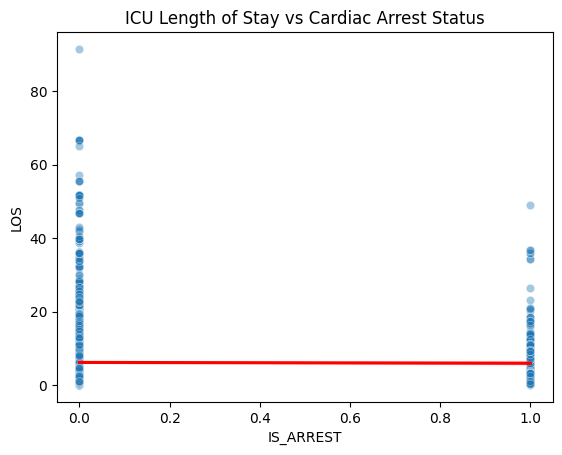

In [ ]:
## scatterplot and regression plot
sns.scatterplot(data=df_h2, x='IS_ARREST', y='LOS', alpha=0.4)
sns.regplot(data=df_h2, x='IS_ARREST', y='LOS', scatter=False, color='red')
plt.title("ICU Length of Stay vs Cardiac Arrest Status")
plt.show()

**Regression Plot**

The regression plot shows two overlapping clusters of LOS values and a nearly flat fitted line, indicating minimal difference in mean length of stay between arrest and non-arrest patients in the linear model.

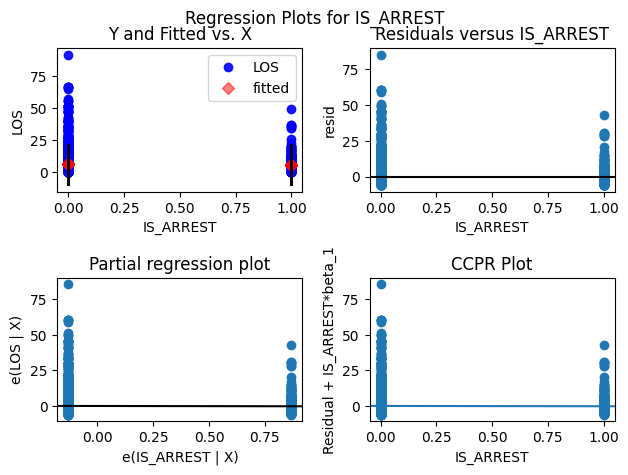

In [ ]:
## regression analysis
sm.graphics.plot_regress_exog(h2_model, 'IS_ARREST')
plt.show()

**2x2 Regression Plots + Residual Plots**

Across all four diagnostic plots, the residual patterns reflect the binary nature of the predictor (IS_ARREST) rather than problems with model fit. The residuals naturally form two clusters, one for arrest and one for non-arrest patients, which produces apparent heteroskedasticity and limits the usefulness of linear regression diagnostics. As a result, the OLS model should be interpreted as a simple comparison of group means, while the Mann-Whitney U test provides a more appropriate and reliable assessment of differences in ICU length of stay.

In [ ]:
from scipy.stats import mannwhitneyu
##mann-whitney U test
los_arrest = df_h2[df_h2['IS_ARREST']==1]['LOS']
los_no_arrest = df_h2[df_h2['IS_ARREST']==0]['LOS']

stat, p_value = mannwhitneyu(los_arrest, los_no_arrest, alternative='two-sided')
print("Mann-Whitney U statistic:", stat)
print("p-value:", p_value)


Mann-Whitney U statistic: 504299.5
p-value: 0.047066380951770154


**Mann-whitney U Test**

We chose to conduct the Mann-Whitney U test because our LOS is right-skewed and does not satisfy the normality assumptions required for a t-test, and because our predictor (IS_ARREST) is binary.


We obtained a U statistic of 504,299.5 and a p-value of 0.047. Using a significance level of α = 0.05, the p-value of approximation is smaller than our α. This means we **reject the null hypothesis** that LOS distributions are the same for arrest and non-arrest patients.


Even though the regression plot shows a nearly flat fitted line, indicating minimal difference in mean LOS between arrest and non-arrest patients, this does not conflict with the Mann-Whitney U result. The OLS regression focuses solely on mean differences, whereas the Mann-Whitney test evaluates whether the overall LOS distributions differ between groups. Because LOS is highly skewed, it is possible for the means to appear similar while the distributions differ in ways that the Mann-Whitney test can detect, like differences in medians, tails, or overall shape. Thus, the Mann-Whitney result reflects distributional differences that a simple linear model does not capture. As a result, we should rely on the Mann-Whitney result when drawing conclusions about differences in ICU length of stay.

## 5. Evaluation of Significance


**Hypothesis 1: Admission Type of Cardiac Arrest**


1.  Binary cutoff model (Age ≥ 65)


Logistic regression with outcome IS_ARREST and predictor AGE65_PLUS. We got an odds ratio of 0.77, with a 95% confidence interval of (0.62, 0.95) and a p-value of 0.0168. Because the p-value is below 0.05, we reject the null hypothesis and conclude that the two age groups (≥ 65 and < 65) are significantly associated with cardiac arrest. However, the odds ratio is < 1, which means patients over 65 actually have lower odds of arrest than younger patients. This is the opposite of our preregistered expectation that older patients would be at higher risk.


2.  Continuous age model (Age at admission)


Logistic regression with outcome IS_ARREST and predictor AGE_AT_ADMIT (continuous). We got an odds ratio of 0.99 per year, with a 95% confidence interval of (0.984, 0.997) and a p-value of 0.003. Because the p-value is below 0.05, we reject the null hypothesis and conclude that there is a significant association between age and cardiac arrest. The odds ratio is < 1, which indicates that each additional year of age is associated with slightly lower odds of arrest, reinforcing the finding from the binary cutoff model.




**Hypothesis 2: ICU Length of Stay and Cardiac Arrest**


A Mann-Whitney U was conducted to compare ICU length of stay (LOS) between patients who experienced a cardiac arrest and those who did not. The test returned a U statistic of 504,299.5 and a p-value of 0.0471. Because the p-value is < 0.05, we reject the null hypothesis and conclude that cardiac arrest status is significantly associated with differences in ICU length of stay. Although the OLS regression model showed only a small difference in mean LOS between the two groups, LOS is highly skewed, and the non-parametric Mann-Whitney test is more appropriate for detecting differences in distribution. Therefore, the significant result indicates that arrest and non-arrest patients differ meaningfully in their LOS distributions, even if their mean values appear similar in the regression plot.









## 6. Conclusions


For our first hypothesis, the first step was to apply a logistic regression/ binary cutoff model. We fail to reject our null hypothesis (with/ a p-value of 0.0168), so there is a association between being over the age of 65 and experiencing a greater likelihood of in‑hospital cardiac arrest among sepsis patients. An odds ratio value of 0.77, which is less than 1, predicts that older patients have a lower risk of experiencing cardiac arrest.


Following this, we introduced a new logistic regression/ continuous age model in order to see if the coefficients corroborated their predictions. With a p-value of 0.003, we reject the null hypothesis and conclude that there is a significant association between age and cardiac arrest cases. Furthermore, with an odds ratio of 0.99, which is less than 1, the risk of arrest decreases with an increase in age.


We took a different approach for our second research question and applied the OLS regression model along with a Mann-Whitney test as a supporting test to detect the differences between the length of stay and arrest and non-arrest patients. The OLS regression model showed only a minimal difference in mean LOS between the groups, but because LOS is highly skewed and varies widely, this model was used primarily for descriptive visualization. The Mann-Whitney test is more appropriate for computing skewed distributions, and it returned a p-value of 0.047, allowing us to reject the null and conclude that the LOS distribution differs significantly between arrest and non-arrest patients. This means that cardiac arrest status is associated with a significant difference in ICU length of stay, even if the average LOS difference appears small in the linear model.


After analyzing both hypotheses, we can reach a conclusion that shows that both the admission type for the cardiac arrest and the ICU length of stay for patients predict meaningful differences in their respective associations. However, despite both of our explorations into each hypothesis being statistically significant, we have to ask ourselves how these interpretations apply to our health care systems in the real world and if they even make sense. Regarding the first hypothesis, is it really plausible (although statistically significant) for older patients to have a correlation with decreased risk in cardiac arrests?





## 7. Limitations

While these results are promising, several limitations must be acknowledged:

* First, the MIMIC-III database represents a single-center cohort from Beth Israel Deaconess Medical Center, which may limit the generalizability of our findings to other hospitals or less acute care settings.
* Second, age values are capped at 89 years due to HIPAA de-identification requirements, which may attenuate the observed effects among the oldest patients.
* Third, the distribution of admission types is highly imbalanced, with nearly all sepsis patients admitted as emergencies; this imbalance reduces the statistical power of comparisons and may exaggerate associations.
* Fourth, while p‑values below 0.05 indicate statistical significance, they do not measure clinical importance. Small but statistically significant differences (e.g., odds ratios near 1.0) may have negligible impact on patient care. Conversely, non‑significant results may still reflect real associations obscured by sample size or measurement error. Overreliance on p‑values risks dismissing clinically relevant signals or exaggerating trivial ones.
* Finally, our models use static variables (age, admission type, ICD codes) rather than dynamic time‑series data such as vital signs, labs, or treatment interventions. Without these richer features, we cannot capture the evolving risk of arrest or the nuanced impact on ICU length of stay. Translating findings into real‑time practice would require integration with continuous monitoring systems, which raises challenges around alarm fatigue, workflow disruption, and equitable access to advanced analytics.

These limitations emphasize the need for cautious interpretation and highlight areas for future work, including validation across diverse settings and incorporation of richer time-series features.

## 8. Acknowledgement

We would like to acknowledge our professor as well as the TAs of INFO 2950 for providing guidance and feedback throughout the project. We also want to thank the creators and maintainers of the MIMIC-III dataset for making high-quality clinical data that are accessible for research and education, and for allowing us to study with this sensitive but important data. Finally, we appreciate our classmates who have been helpful in providing feedback during peer review.

### Bibliography
Johnson, A., Pollard, T., & Mark, R. (2016, September 4). *MIMIC-III Clinical Database*. Physionet.org. https://physionet.org/content/mimiciii/1.4/

Lee, H.-Y., Kuo, P.-C., Qian, F., Li, C.-H., Hu, J.-R., Hsu, W.-T., Hong-Jie Jhou, Chen, P.-H., Lee, C.-H., Su, C.-H., Liao, P.-C., Wu, I-Ju., & Lee, C.-C. (2024). Prediction of In-Hospital Cardiac Arrest in the Intensive Care Unit: Machine Learning–Based Multimodal Approach. *JMIR Medical Informatics*, 12(39051152), e49142–e49142. https://doi.org/10.2196/49142

Pandas. (n.d.). *Indexing and selecting data — pandas 1.3.5 documentation*. Pandas.pydata.org. Retrieved December 4, 2025, from https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

SciPy. (n.d.). *scipy.stats.mannwhitneyu — SciPy v1.7.1 Manual*. Docs.scipy.org. Retrieved December 4, 2025, from https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html

In [ ]:
!jupyter nbconvert --to html /content/Phase_V.ipynb

[NbConvertApp] Converting notebook /content/Phase_V.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 467105 bytes to /content/Phase_V.html
